# BME 2301 - FINAL PROJECT 2026

## Project Title: Brain Tumor Classification

**Student Names**: Caitlin Bui and Ally Lin

**Research Question**: How can we develop a machine learning model that analyzes MRI medical imaging data to accurately classify and identify different types of brain tumors?

## Our Data ##

We used a Brain Tumor MRI dataset from Kaggle. It contains a total of 7,200 human brain MRI images, and is categorized into four classes: Glioma, Meningioma, Pituitary Tumor, and No tumor. Each class contains 400 images. We have a training set with a total of 5,600 images, with 1,400 images for each class, and a testing set with a total of 1,600 images, 400 images for each class. 

## Loading our Dataset: ##

In [122]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf 
from tensorflow import keras 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

dataset_path = r"C:/Users/CmeKa/OneDrive/Desktop/BiomedicalComputing/Training"

data = []
labels = []

classes = [folder for folder in os.listdir(dataset_path) 
           if os.path.isdir(os.path.join(dataset_path, folder))]

print("Classes:", classes)

for label in classes:
    folder = os.path.join(dataset_path, label)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            image = Image.open(img_path)
            data.append(image)
            labels.append(label)
        except Exception as e:
            print(f"Could not load {img_path}: {e}")

print("Number of images loaded:", len(data))
print("Number of labels loaded:", len(labels))

#TESTING SET
test_path = r"C:/Users/CmeKa/OneDrive/Desktop/BiomedicalComputing/Testing"

test_data = []
test_labels = []

for label in classes:
    folder = os.path.join(test_path, label)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            image = Image.open(img_path)
            image = image.convert("L")
            image = image.resize((224, 224))
            image_array = np.array(image)
            test_data.append(image_array)
            test_labels.append(label)
        except Exception as e:
            print(f"Could not load {img_path}: {e}")

X_test = np.array(test_data, dtype="float32") / 255.0
X_test = X_test.reshape(-1, 224, 224, 1)

encoder = LabelEncoder()
encodedlabels = encoder.fit_transform(labels)

y_test = encoder.transform(test_labels)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of images loaded: 5600
Number of labels loaded: 5600
X_test shape: (1600, 224, 224, 1)
y_test shape: (1600,)


## Exploratory Data Analysis ##

We wanted to display an image from each tumor category to visually see the difference in tumor types: 

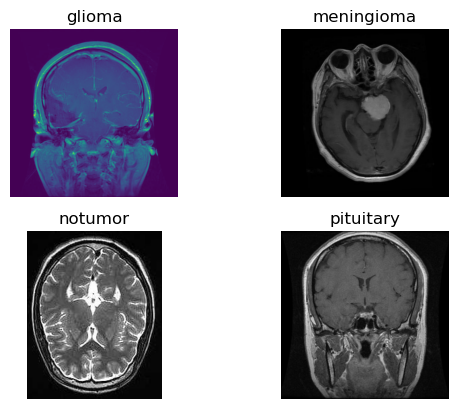

In [123]:
index0 = labels.index(classes[0])
plt.subplot(2, 2, 1)
plt.imshow(data[index0])
plt.title(classes[0])
plt.axis("off")

index1 = labels.index(classes[1])
plt.subplot(2, 2, 2)
plt.imshow(data[index1])
plt.title(classes[1])
plt.axis("off")

index2 = labels.index(classes[2])
plt.subplot(2, 2, 3)
plt.imshow(data[index2])
plt.title(classes[2])
plt.axis("off")

index3 = labels.index(classes[3])
plt.subplot(2, 2, 4)
plt.imshow(data[index3])
plt.title(classes[3])
plt.axis("off")

plt.show()

To further look at the variation in the images, we decided to look at more images from each tumor class:

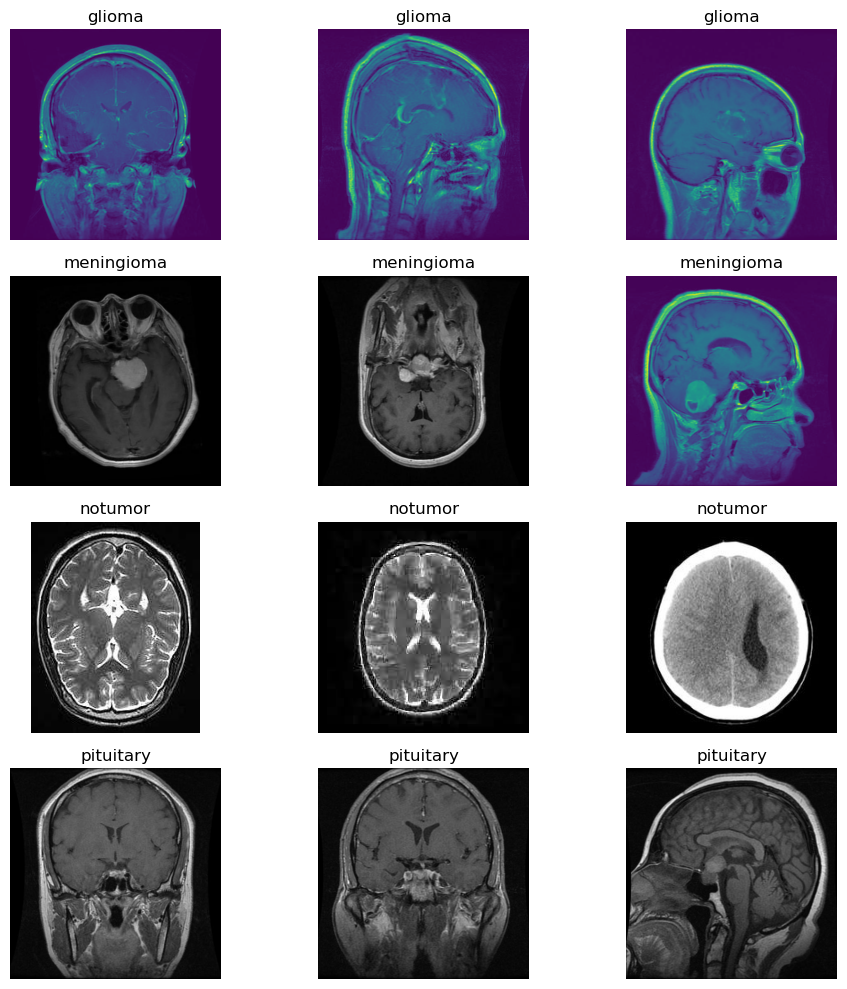

In [124]:
samples = 3
position = 1
plt.figure(figsize=(10, 10))
for label in classes:
    count = 0
    for i in range(len(data)):
        if labels[i] == label:
            plt.subplot(len(classes), samples, position)
            plt.imshow(data[i])   
            plt.title(label)
            plt.axis("off")
            position += 1
            count += 1
            if count == samples:
                break
plt.tight_layout()
plt.show()

We notice that there is variation between the images. The images differ in colors and image size/dimensions. To further examine our images, we decided to 

Min pixel value: 0
Max pixel value: 255


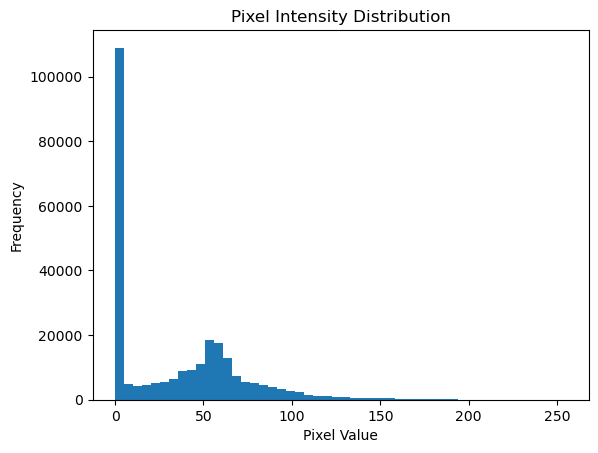

In [125]:
imagearray = np.array(data[0])
print("Min pixel value:", imagearray.min())
print("Max pixel value:", imagearray.max())

plt.hist(imagearray.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

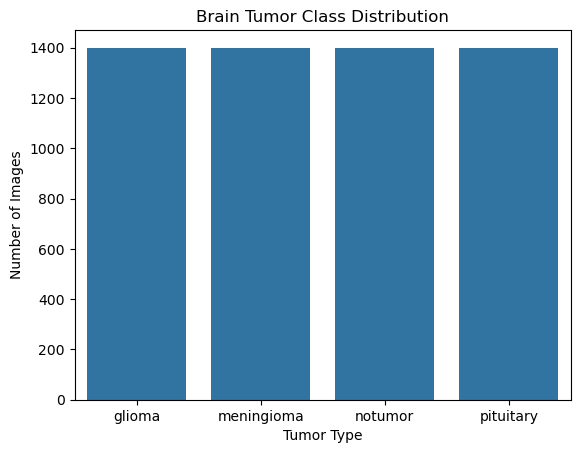

In [126]:
sns.countplot(x = labels)
plt.title("Brain Tumor Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.show()

## Preprocessing ##

First, we decided to convert all the images to grayscale, resized them to 224 x 224 pixels, and converted the images into numbers using a NumPy array. To follow that, we also normalized the pixel values from a range of 0 to 255 to a range of 0 and 1. 

In [127]:
cleaneddata = []

for image in data:
    image = image.convert("L") #Grayscale 
    image = image.resize((224,224)) #Resizing
    cleaneddata.append(np.array(image))

cleaneddata = np.array(cleaneddata)
labels = np.array(labels)

cleaneddata = cleaneddata / 255.0 #Normalizing 

print(cleaneddata.shape)
print(cleaneddata.min()) 
print(cleaneddata.max())

(5600, 224, 224)
0.0
1.0


To check if our preprocessing worked, we displayed the preprocessed versions of our images from earlier. 

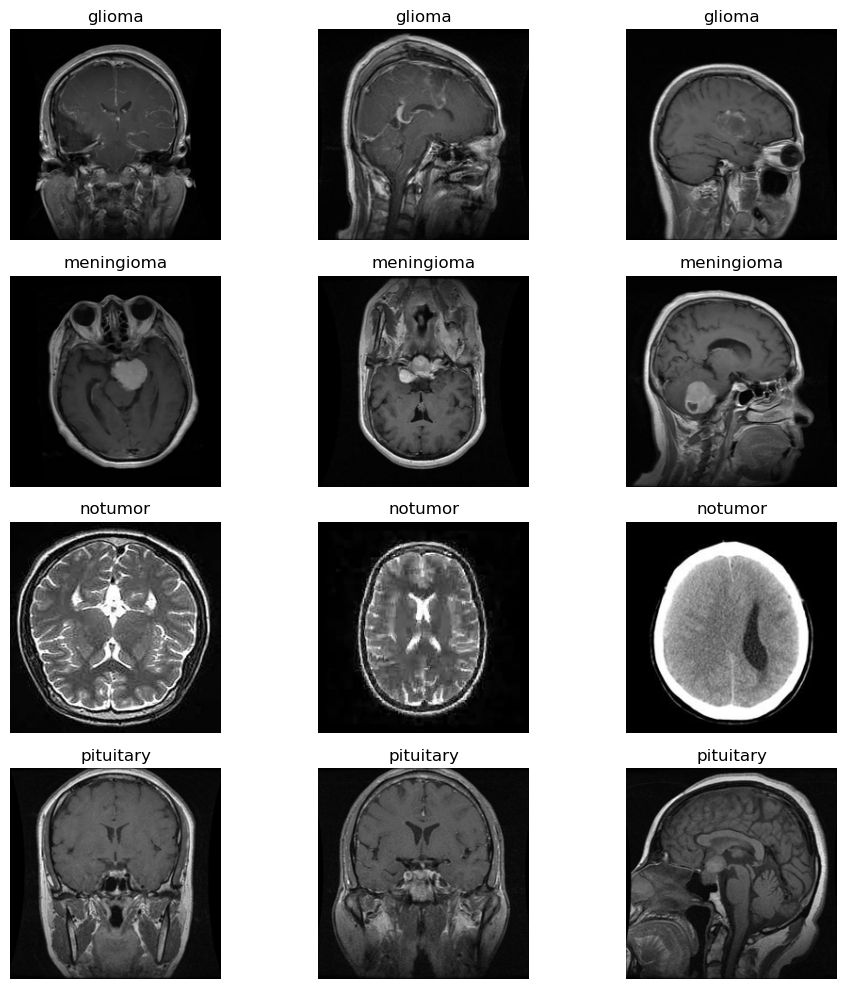

In [128]:
samples = 3
position = 1

plt.figure(figsize=(10, 10))

for label in classes:
    count = 0
    for i in range(len(cleaneddata)):
        if labels[i] == label:
            plt.subplot(len(classes), samples, position)
            plt.imshow(cleaneddata[i], cmap="gray")
            plt.title(label)
            plt.axis("off")
            
            position += 1
            count += 1
            
            if count == samples:
                break

plt.tight_layout()
plt.show()

# BASELINE MODEL #

Class names: ['glioma' 'meningioma' 'notumor' 'pituitary']
cleaneddata shape after reshape: (5600, 224, 224, 1)
X_train shape: (4480, 224, 224, 1)
X_valid shape: (1120, 224, 224, 1)
y_train shape: (4480,)
y_valid shape: (1120,)
X_test shape: (1600, 224, 224, 1)
y_test shape: (1600,)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_28 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 300)            │    15,053,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,083,604 (57.54 MB)

 Trainable params: 15,083,604 (57.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.5042 - loss: 1.0999 - val_accuracy: 0.4688 - val_loss: 1.0420
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6598 - loss: 0.8298 - val_accuracy: 0.6911 - val_loss: 0.7940
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.7154 - loss: 0.7169 - val_accuracy: 0.7384 - val_loss: 0.7052
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7663 - loss: 0.6123 - val_accuracy: 0.7464 - val_loss: 0.6796
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7710 - loss: 0.5910 - val_accuracy: 0.7473 - val_loss: 0.6659
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8062 - loss: 0.5184 - val_accuracy: 0.7768 - val_loss: 0.5937
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.8185 - loss: 0.4746 - val_accuracy: 0.7875 - val_loss: 0.5645
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.8449 - loss: 0.4213 - val

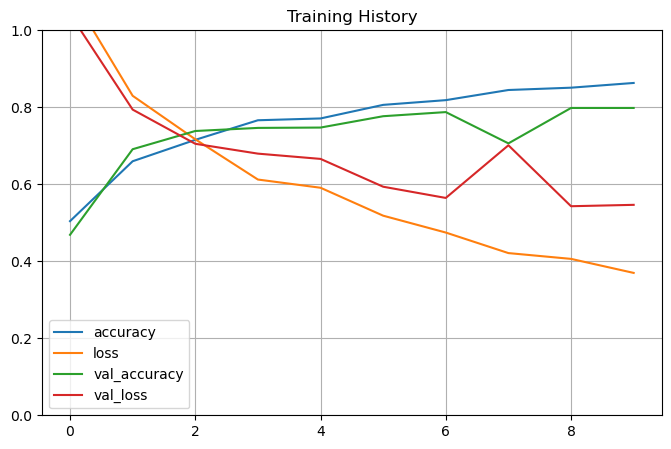

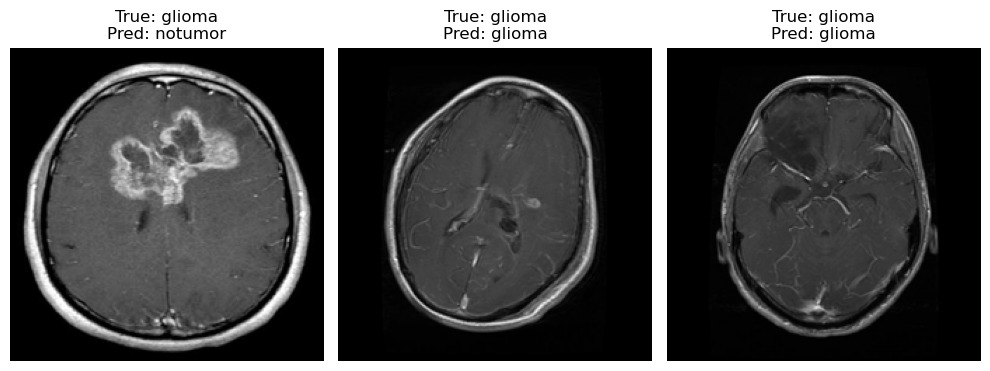

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7144 - loss: 0.9495
Test loss: 0.9494734406471252
Test accuracy: 0.7143750190734863
Test accuracy: 71.44%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
[[0.05 0.01 0.94 0.  ]
 [0.43 0.13 0.39 0.05]
 [0.56 0.07 0.34 0.02]]
True labels: ['glioma' 'glioma' 'glioma']
Predicted labels: ['notumor' 'glioma' 'glioma']


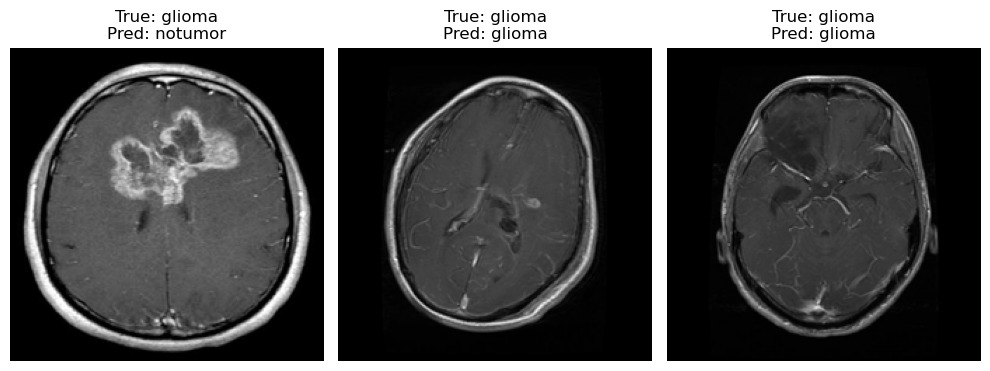

In [129]:
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
class_names = encoder.classes_
print("Class names:", class_names)

cleaneddata = cleaneddata.reshape(-1, 224, 224, 1)
print("cleaneddata shape after reshape:", cleaneddata.shape)

X_train, X_valid, y_train, y_valid = train_test_split(
    cleaneddata,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

test_data = []
test_labels = []

for label in classes:
    folder = os.path.join(test_path, label)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            image = Image.open(img_path)
            image = image.convert("L")
            image = image.resize((224, 224))
            image_array = np.array(image)

            test_data.append(image_array)
            test_labels.append(label)

        except Exception as e:
            print(f"Could not load {img_path}: {e}")

X_test = np.array(test_data, dtype="float32") / 255.0
X_test = X_test.reshape(-1, 224, 224, 1)
y_test = encoder.transform(test_labels)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

model = keras.models.Sequential()
model.add(keras.Input(shape=(224, 224, 1)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(4, activation="softmax"))
model.summary()

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_valid, y_valid)
)

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("Training History")
plt.show()

plt.figure(figsize=(10, 4))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(X_test[i].reshape(224, 224), cmap="gray")
    plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test accuracy: {:.2f}%".format(test_accuracy * 100))

X_new = X_test[:3]
y_proba = model.predict(X_new)
print(y_proba.round(2))

y_pred = np.argmax(y_proba, axis=1)

predicted_labels = encoder.inverse_transform(y_pred)
true_labels = encoder.inverse_transform(y_test[:3])

print("True labels:", true_labels)
print("Predicted labels:", predicted_labels)

plt.tight_layout()
plt.show()

In [130]:
model.evaluate(X_test, y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7144 - loss: 0.9495


[0.9494734406471252, 0.7143750190734863]

Baseline Model Results: Around 95% Test Loss, and around 70% Test Accuracy. We want to try and improve our model by minimizing test loss and improving test accuracy.

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


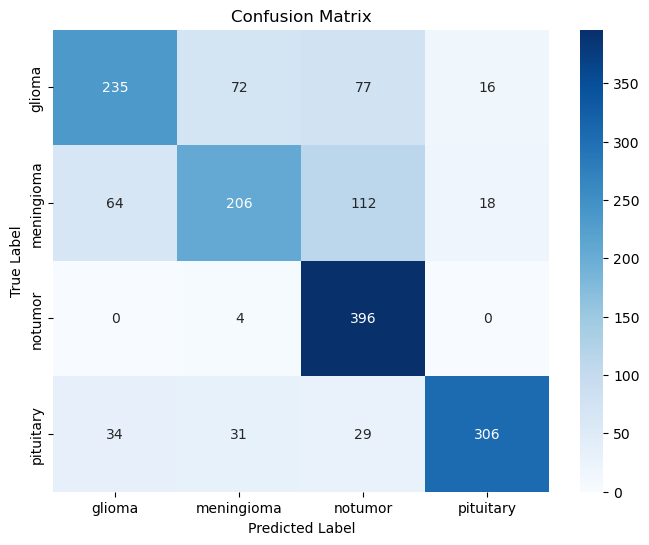

In [131]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_proba = model.predict(X_test)
y_pred = np.argmax(y_proba, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Improving Outcomes #

Model w/ a different learning rate:

In [132]:
model2 = keras.models.Sequential()
model2.add(keras.Input(shape=(224, 224, 1)))
model2.add(keras.layers.Flatten())
model2.add(keras.layers.Dense(300, activation="relu"))
model2.add(keras.layers.Dense(100, activation="relu"))
model2.add(keras.layers.Dense(4, activation="softmax"))

model2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    metrics=["accuracy"]
)

history = model2.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_valid, y_valid)
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.5100 - loss: 1.1587 - val_accuracy: 0.6295 - val_loss: 1.0224
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.6480 - loss: 0.9472 - val_accuracy: 0.6804 - val_loss: 0.9091
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.6944 - loss: 0.8433 - val_accuracy: 0.7000 - val_loss: 0.8532
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.7219 - loss: 0.7767 - val_accuracy: 0.7170 - val_loss: 0.8009
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7511 - loss: 0.7228 - val_accuracy: 0.7063 - val_loss: 0.7855
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7625 - loss: 0.6846 - val_accuracy: 0.7312 - val_loss: 0.7462
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7757 - loss: 0.6528 - val_accuracy: 0.7393 - val_loss: 0.7231
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.7830 - loss: 0.6214 - va

In [133]:
model2.evaluate(X_test, y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7063 - loss: 0.8729


[0.8729403614997864, 0.706250011920929]

Model w/ Different Optimization Function: 

In [134]:
model3 = keras.models.Sequential()
model3.add(keras.Input(shape=(224, 224, 1)))
model3.add(keras.layers.Flatten())
model3.add(keras.layers.Dense(300, activation="relu"))
model3.add(keras.layers.Dense(100, activation="relu"))
model3.add(keras.layers.Dense(4, activation="softmax"))

model3.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = model3.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_valid, y_valid)
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6083 - loss: 1.5363 - val_accuracy: 0.7179 - val_loss: 0.8031
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.7536 - loss: 0.6596 - val_accuracy: 0.7071 - val_loss: 0.9085
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7763 - loss: 0.5892 - val_accuracy: 0.7598 - val_loss: 0.6824
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.7998 - loss: 0.5295 - val_accuracy: 0.7955 - val_loss: 0.6455
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.8306 - loss: 0.4691 - val_accuracy: 0.7723 - val_loss: 0.6702
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.8571 - loss: 0.3905 - val_accuracy: 0.7571 - val_loss: 0.7603
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9004 - loss: 0.2878 - val_accuracy: 0.7759 - val_loss: 0.6575
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9025 - loss: 0.2643 

In [135]:
model3.evaluate(X_test, y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7900 - loss: 1.0018


[1.001772403717041, 0.7900000214576721]

Model w/ greater amount of neurons + extra layer of neurons 

In [136]:
model4 = keras.models.Sequential()
model4.add(keras.Input(shape=(224, 224, 1)))
model4.add(keras.layers.Flatten())
model4.add(keras.layers.Dense(500, activation="relu"))
model4.add(keras.layers.Dense(200, activation="relu"))
model4.add(keras.layers.Dense(4, activation="softmax"))

model4.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

history = model4.fit(
    X_train,
    y_train,
    epochs=12,
    validation_data=(X_valid, y_valid)
)

Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.5259 - loss: 1.0744 - val_accuracy: 0.6036 - val_loss: 0.9296
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.6665 - loss: 0.8046 - val_accuracy: 0.6759 - val_loss: 0.7680
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7299 - loss: 0.6808 - val_accuracy: 0.6107 - val_loss: 0.8928
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7658 - loss: 0.5978 - val_accuracy: 0.6991 - val_loss: 0.7159
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.7951 - loss: 0.5323 - val_accuracy: 0.7518 - val_loss: 0.6405
Epoch 6/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.8234 - loss: 0.4740 - val_accuracy: 0.7589 - val_loss: 0.6296
Epoch 7/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.8241 - loss: 0.4526 - val_accuracy: 0.7723 - val_loss: 0.5919
Epoch 8/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8429 - loss: 0.4169 - val_

In [137]:
model4.evaluate(X_test, y_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7669 - loss: 0.8278


[0.8277875781059265, 0.7668750286102295]

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


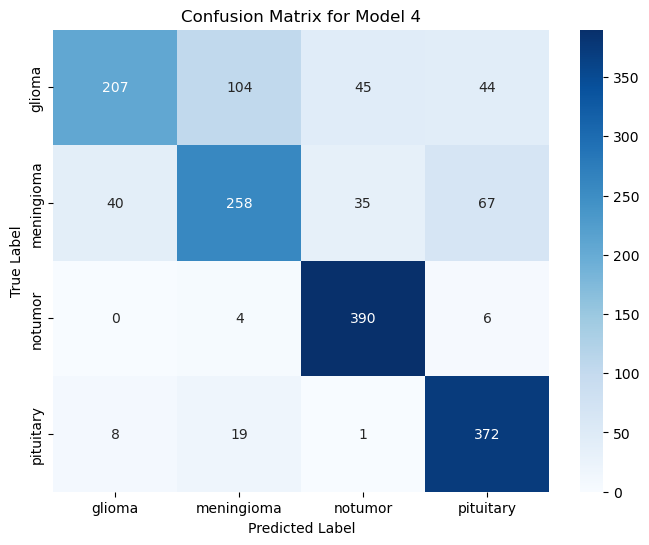

In [138]:
y_proba = model4.predict(X_test)
y_pred = np.argmax(y_proba, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Model 4")
plt.show()